# Customer Churn - Exploratory Data Analysis

This notebook is the *analysis* companion to the modelling code in `src/`.
It answers four questions before any model is fitted:

1. What does the data look like, and where is it missing?
2. How imbalanced is the target, and which raw signals separate the classes?
3. Are there interactions that a linear model would miss?
4. Do the two suspicious-looking columns (`churn_risk_score_v0`,
   `account_flagged_for_review`) actually leak the label?

The dataset is **synthetic** and produced offline by `data/generate_data.py`
with a fixed seed - see the README for the latent process.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import config
from src.data import make_splits
from src.features import FeatureEngineer

sns.set_theme(style="whitegrid", palette=config.PALETTE)
pd.set_option("display.width", 120, "display.max_columns", 40)
FIG = config.FIGURE_DIR

df = pd.read_csv(config.RAW_DATA_PATH)
print(f"rows={len(df):,}  columns={df.shape[1]}")
df.head()

rows=15,000  columns=17


,customer_id,tenure_months,monthly_charges,total_charges,contract_type,payment_method,internet_service,num_support_tickets,avg_monthly_usage_gb,has_streaming,is_senior,num_dependents,region,last_login_days,churn_risk_score_v0,account_flagged_for_review,churn
0,CUST-000001,7,71.89,475.69,Month-to-month,Electronic check,Fiber optic,1,281.8,1,0,1.0,East,4.0,7.75,0,1
1,CUST-000002,59,92.94,5325.80,One year,Credit card (automatic),Fiber optic,2,547.8,1,0,1.0,East,6.0,62.92,0,0
2,CUST-000003,48,70.55,3003.57,Two year,Bank transfer (automatic),DSL,0,98.8,1,0,1.0,South,6.0,11.50,1,0
3,CUST-000004,11,70.28,717.84,Month-to-month,Credit card (automatic),DSL,0,228.2,1,0,1.0,South,22.0,51.64,0,0
4,CUST-000005,27,79.67,2305.67,Month-to-month,Credit card (automatic),Fiber optic,2,290.7,0,0,1.0,North,9.0,6.83,0,0


## 1. Schema, dtypes and missingness

In [2]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
profile

,dtype,n_missing,pct_missing,n_unique
customer_id,str,0,0.00,15000
tenure_months,int64,0,0.00,72
monthly_charges,float64,0,0.00,6389
total_charges,float64,749,4.99,13913
contract_type,str,0,0.00,3
payment_method,str,0,0.00,4
internet_service,str,254,1.69,3
num_support_tickets,int64,0,0.00,8
avg_monthly_usage_gb,float64,598,3.99,5589
has_streaming,int64,0,0.00,2


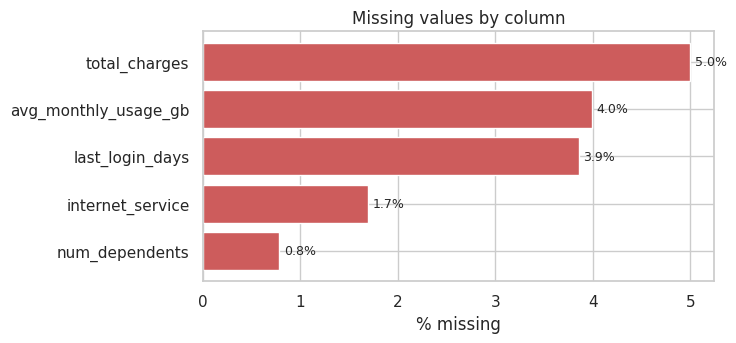

tenure_months
tenure > 2m     0.014
tenure <= 2m    0.545
Name: missing_total, dtype: float64


In [3]:
miss = (df.isna().mean() * 100)
miss = miss[miss > 0].sort_values()
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(miss.index, miss.values, color="indianred")
ax.set_xlabel("% missing")
ax.set_title("Missing values by column")
for i, v in enumerate(miss.values):
    ax.text(v + 0.05, i, f"{v:.1f}%", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "eda_missingness.png", dpi=config.FIG_DPI)
plt.show()

# Missingness in total_charges is concentrated in brand-new accounts:
print(df.assign(missing_total=df.total_charges.isna())
        .groupby(df.tenure_months <= 2)["missing_total"].mean().rename(
            index={True: "tenure <= 2m", False: "tenure > 2m"}).round(3))

## 2. Target balance and univariate separation

~26% of customers churn: imbalanced enough that accuracy is a useless headline
metric, which is why the project reports PR-AUC and picks a cost-based
threshold instead of the default 0.5.

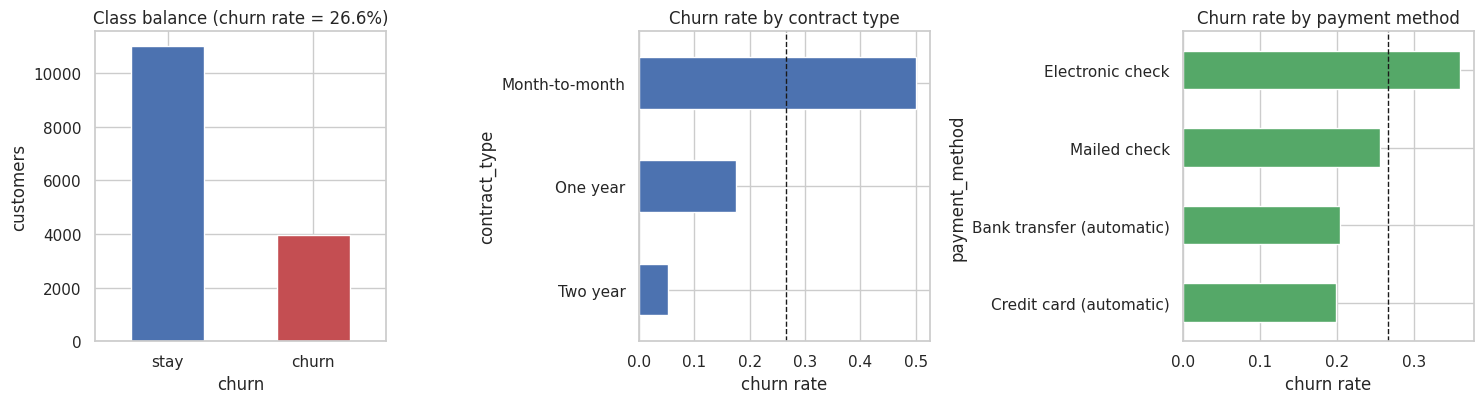

In [4]:
rate = df[config.TARGET].mean()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

df[config.TARGET].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color=["#4c72b0", "#c44e52"])
axes[0].set_xticklabels(["stay", "churn"], rotation=0)
axes[0].set_title(f"Class balance (churn rate = {rate:.1%})")
axes[0].set_ylabel("customers")

(df.groupby("contract_type")[config.TARGET].mean().sort_values()
   .plot(kind="barh", ax=axes[1], color="#4c72b0"))
axes[1].axvline(rate, color="k", ls="--", lw=1)
axes[1].set_title("Churn rate by contract type")
axes[1].set_xlabel("churn rate")

(df.groupby("payment_method")[config.TARGET].mean().sort_values()
   .plot(kind="barh", ax=axes[2], color="#55a868"))
axes[2].axvline(rate, color="k", ls="--", lw=1)
axes[2].set_title("Churn rate by payment method")
axes[2].set_xlabel("churn rate")

fig.tight_layout()
fig.savefig(FIG / "eda_churn_rates.png", dpi=config.FIG_DPI)
plt.show()

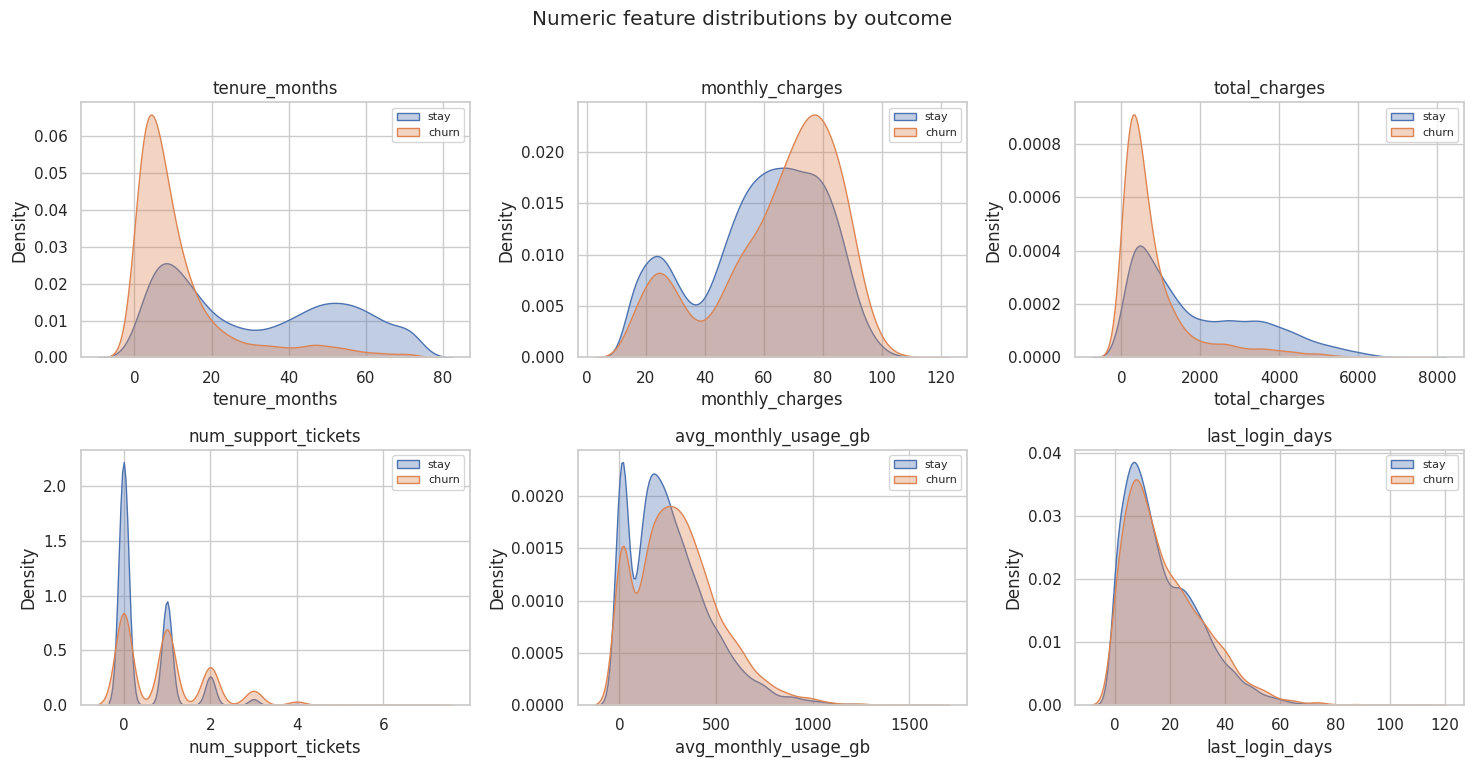

In [5]:
num_cols = ["tenure_months", "monthly_charges", "total_charges",
            "num_support_tickets", "avg_monthly_usage_gb", "last_login_days"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, col in zip(axes.ravel(), num_cols):
    for label, sub in df.groupby(config.TARGET):
        sns.kdeplot(sub[col].dropna(), ax=ax, fill=True, alpha=0.35,
                    label="churn" if label else "stay", warn_singular=False)
    ax.set_title(col)
    ax.legend(fontsize=8)
fig.suptitle("Numeric feature distributions by outcome", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "eda_numeric_distributions.png", dpi=config.FIG_DPI,
            bbox_inches="tight")
plt.show()

In [6]:
from sklearn.metrics import roc_auc_score

rows = []
for col in config.NUMERIC_FEATURES:
    s = df[col].fillna(df[col].median())
    rows.append({"feature": col,
                 "univariate_auc": roc_auc_score(df[config.TARGET], s),
                 "point_biserial_r": np.corrcoef(s, df[config.TARGET])[0, 1]})
uni = pd.DataFrame(rows).assign(
    strength=lambda d: (d.univariate_auc - 0.5).abs()
).sort_values("strength", ascending=False).drop(columns="strength")
uni.round(3)

,feature,univariate_auc,point_biserial_r
0,tenure_months,0.217,-0.398
2,total_charges,0.285,-0.300
3,num_support_tickets,0.632,0.244
1,monthly_charges,0.588,0.120
4,avg_monthly_usage_gb,0.565,0.090
6,last_login_days,0.522,0.038
5,num_dependents,0.492,-0.018
7,churn_risk_score_v0,0.495,-0.008


## 3. Interactions

The generator embeds genuine interactions - price sensitivity is much stronger
for customers without a lock-in, and heavy spenders who barely use the service
are the worst risk of all. This is why tree ensembles edge out the logistic
regression.

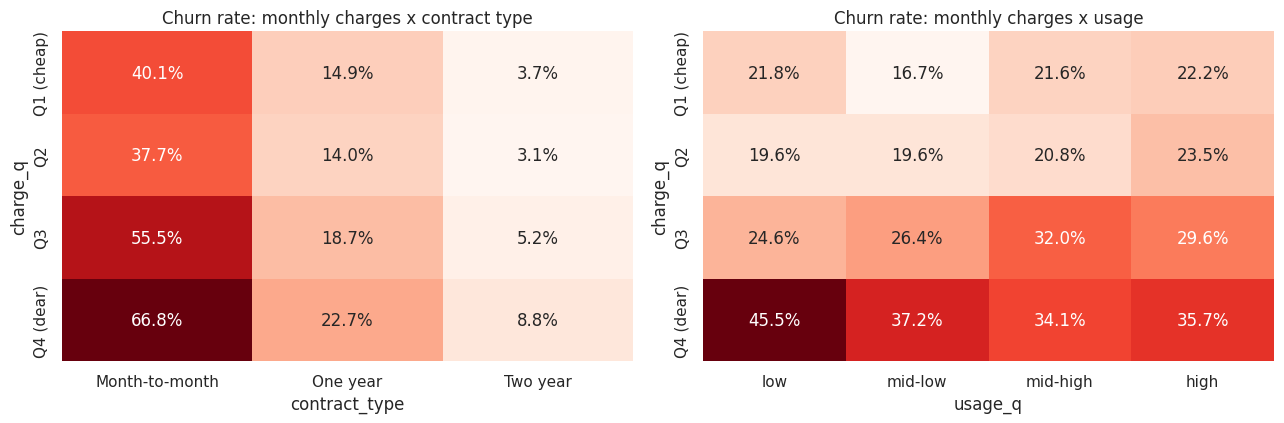

price sensitivity (Q4 - Q1 churn rate) by contract:
contract_type
Month-to-month    0.267
One year          0.079
Two year          0.051
dtype: float64


In [7]:
tmp = df.assign(
    charge_q=pd.qcut(df.monthly_charges, 4, labels=["Q1 (cheap)", "Q2", "Q3", "Q4 (dear)"]),
    usage_q=pd.qcut(df.avg_monthly_usage_gb, 4,
                    labels=["low", "mid-low", "mid-high", "high"]),
)
pivot = tmp.pivot_table(index="charge_q", columns="contract_type",
                        values=config.TARGET, aggfunc="mean", observed=True)
pivot2 = tmp.pivot_table(index="charge_q", columns="usage_q",
                         values=config.TARGET, aggfunc="mean", observed=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="Reds", ax=axes[0], cbar=False)
axes[0].set_title("Churn rate: monthly charges x contract type")
sns.heatmap(pivot2, annot=True, fmt=".1%", cmap="Reds", ax=axes[1], cbar=False)
axes[1].set_title("Churn rate: monthly charges x usage")
fig.tight_layout()
fig.savefig(FIG / "eda_interactions.png", dpi=config.FIG_DPI)
plt.show()

print("price sensitivity (Q4 - Q1 churn rate) by contract:")
print((pivot.iloc[-1] - pivot.iloc[0]).round(3))

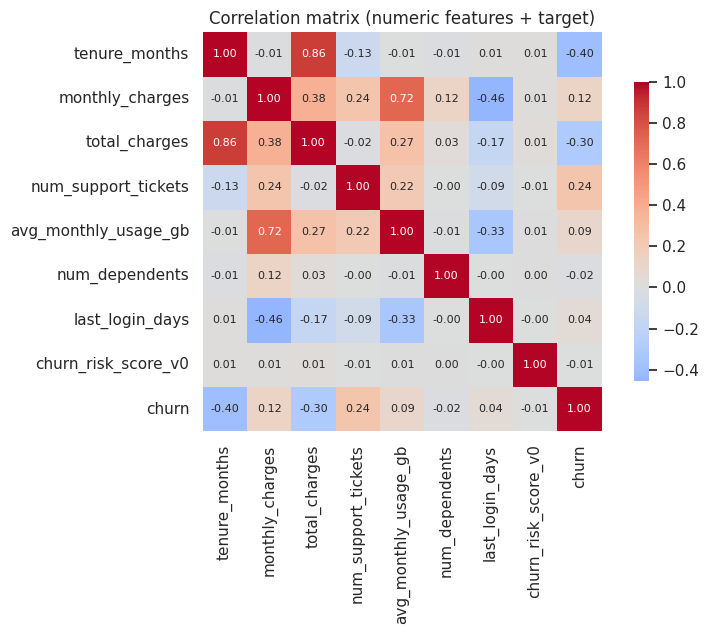

In [8]:
corr = df[config.NUMERIC_FEATURES + [config.TARGET]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, ax=ax, cbar_kws={"shrink": 0.75}, annot_kws={"size": 8})
ax.set_title("Correlation matrix (numeric features + target)")
fig.tight_layout()
fig.savefig(FIG / "eda_correlation.png", dpi=config.FIG_DPI)
plt.show()

## 4. Red herrings: do the suspicious columns leak?

`churn_risk_score_v0` (a "legacy risk score") and `account_flagged_for_review`
(a back-office flag) both *sound* like post-outcome information. They are drawn
independently of the latent churn process, and the numbers below confirm it -
both sit on top of AUC 0.50. They are kept as model inputs precisely so that the
importance plots demonstrate the model ignores them.

In [9]:
checks = []
for col in config.RED_HERRING_FEATURES:
    s = df[col].fillna(0)
    churn_mean = df.loc[df[config.TARGET] == 1, col].mean()
    stay_mean = df.loc[df[config.TARGET] == 0, col].mean()
    checks.append({"column": col,
                   "auc": round(roc_auc_score(df[config.TARGET], s), 4),
                   "mean_if_churn": round(float(churn_mean), 3),
                   "mean_if_stay": round(float(stay_mean), 3)})
pd.DataFrame(checks)

,column,auc,mean_if_churn,mean_if_stay
0,churn_risk_score_v0,0.4948,49.990,50.511
1,account_flagged_for_review,0.5010,0.093,0.091


## 5. Engineered features

`FeatureEngineer` (in `src/features.py`) is fitted on the **training split
only**; the cell below fits it on train and applies it to the validation split,
exactly as the pipeline does at training time.

In [10]:
splits = make_splits()
fe = FeatureEngineer().fit(splits.X_train)
eng = fe.transform(splits.X_val)
eng_cols = config.ENGINEERED_NUMERIC + config.ENGINEERED_CATEGORICAL
eng[eng_cols].head(8)

,charges_per_tenure_month,tickets_per_tenure_year,usage_z_by_contract,tenure_bucket
6360,87.825500,0.400000,0.068843,49m+
1192,56.496667,0.000000,-0.219408,13-24m
10465,57.223200,0.480000,-0.226213,25-48m
10851,15.191622,0.324324,-1.739174,25-48m
3111,60.070972,0.000000,0.453676,49m+
10032,43.172000,0.000000,-0.277625,25-48m
14053,68.088824,0.000000,-0.065828,49m+
14801,83.448000,0.000000,0.807239,0-6m


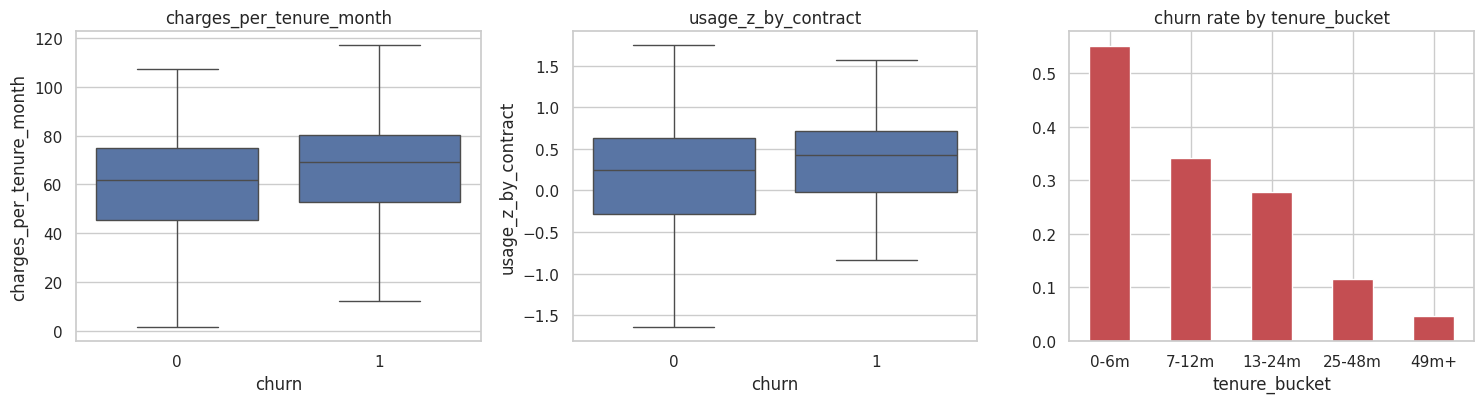

In [11]:
eng_with_y = eng.assign(churn=splits.y_val.values)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.boxplot(data=eng_with_y, x="churn", y="charges_per_tenure_month",
            ax=axes[0], showfliers=False)
axes[0].set_title("charges_per_tenure_month")
sns.boxplot(data=eng_with_y, x="churn", y="usage_z_by_contract",
            ax=axes[1], showfliers=False)
axes[1].set_title("usage_z_by_contract")
(eng_with_y.groupby("tenure_bucket", observed=True)["churn"].mean()
    .reindex(config.TENURE_LABELS).plot(kind="bar", ax=axes[2], color="#c44e52"))
axes[2].set_title("churn rate by tenure_bucket")
axes[2].tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIG / "eda_engineered_features.png", dpi=config.FIG_DPI)
plt.show()

## 6. Modelling results

Loaded from the artifacts written by `make train` / `make evaluate` so the
notebook never re-states numbers by hand.

In [12]:
comparison = pd.read_csv(config.MODEL_COMPARISON_PATH)
comparison[["model", "cv_roc_auc", "val_roc_auc", "val_pr_auc",
            "val_brier", "search_seconds"]].round(4)

,model,cv_roc_auc,val_roc_auc,val_pr_auc,val_brier,search_seconds
0,stacking_ensemble,0.8678,0.8593,0.6959,0.1298,203.8
1,hist_gradient_boosting,0.8660,0.8584,0.6927,0.1291,42.4
2,random_forest,0.8629,0.8558,0.6920,0.1526,175.1
3,gradient_boosting,0.8682,0.8590,0.6910,0.1293,103.4
4,logistic_regression,0.8671,0.8580,0.6863,0.1296,37.9


In [13]:
metrics = json.loads(config.TEST_METRICS_PATH.read_text())
summary = {k: round(metrics[k], 4) for k in
           ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier"]}
summary["threshold"] = metrics["threshold"]
summary["model"] = metrics["model_name"]
print(json.dumps(summary, indent=2))
print("\nconfusion matrix:", metrics["confusion_matrix"])
ev = metrics["expected_value"]
print(f"expected value per customer: {ev['ev_per_customer']:.2f} "
      f"(vs {ev['ev_do_nothing'] / metrics['n_test']:.2f} doing nothing)")

{
  "accuracy": 0.7893,
  "precision": 0.5824,
  "recall": 0.7315,
  "f1": 0.6485,
  "roc_auc": 0.8644,
  "pr_auc": 0.7185,
  "brier": 0.1248,
  "threshold": 0.29,
  "model": "stacking_ensemble"
}

confusion matrix: {'tn': 1785, 'fp': 418, 'fn': 214, 'tp': 583}
expected value per customer: -115.51 (vs -132.83 doing nothing)


## Takeaways

* **Contract type dominates.** Month-to-month customers churn several times more
  often than two-year customers; tenure is the second-strongest signal.
* **Price only bites without lock-in.** The charge x contract heatmap shows the
  interaction that motivates tree ensembles over a plain GLM.
* **The scary-looking columns are noise.** Both red herrings sit at AUC ~0.50 and
  the model's importance ranking puts them at the bottom - a useful reminder that
  a column name is not evidence of leakage (and vice versa).
* **Missingness is structural, not random.** `total_charges` is missing almost
  exclusively for brand-new accounts, so median imputation inside the pipeline
  plus the `tenure_bucket` feature keeps that information usable.